## **Вариант:**
Ерзикова Елизавета Андреевна 6133-010402D.

Классификатор 1 - К-ближайших соседей (К=3),

Классификатор 2 - Логистическая регрессия;

Признаки: alcohol , flavanoids , alcalinity_of_ash

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.datasets import load_wine
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [2]:
# Загрузка датасета WINE
X, y = load_wine(return_X_y=True)

wine = load_wine()
feature_names = wine.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Выбранные признаки
selected_features = ['alcohol', 'flavanoids', 'alcalinity_of_ash']
X = df[selected_features].values

In [3]:
# 2. Подготовка выборок
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Масштабирование признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Функция для вывода метрик
def print_metrics(y_true, y_pred, model_name):
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

    print(f"{model_name}:")
    # Выводим метрики для каждого класса
    for i in range(len(precision_per_class)):
        print(f"    Class {i}: Precision={precision_per_class[i]:.4f}, Recall={recall_per_class[i]:.4f}, F1-score={f1_per_class[i]:.4f}")
    print("-" * 30)

In [4]:
# 3. Построение классификаторов
# Классификатор 1: K-ближайших соседей (K=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print_metrics(y_test, y_pred_knn, "K-Nearest Neighbors (KNN)")

# Классификатор 2: Логистическая регрессия
logistic_regression = LogisticRegression(random_state=42)
logistic_regression.fit(X_train, y_train)
y_pred_lr = logistic_regression.predict(X_test)
print_metrics(y_test, y_pred_lr, "Logistic Regression")

K-Nearest Neighbors (KNN):
    Class 0: Precision=0.8500, Recall=0.9444, F1-score=0.8947
    Class 1: Precision=0.8889, Recall=0.7619, F1-score=0.8205
    Class 2: Precision=0.8750, Recall=0.9333, F1-score=0.9032
------------------------------
Logistic Regression:
    Class 0: Precision=0.8421, Recall=0.8889, F1-score=0.8649
    Class 1: Precision=0.8500, Recall=0.8095, F1-score=0.8293
    Class 2: Precision=0.9333, Recall=0.9333, F1-score=0.9333
------------------------------



## Анализ:
Класс 0: модель K-ближайших соседей (KNN) демонстрирует превосходство над логистической регрессией по всем ключевым метрикам: Precision, Recall и F1-score.

Класс 1: наблюдается смешанная картина. KNN показывает более высокую Precision. Однако логистическая регрессия превосходит KNN по Recall и имеет незначительно лучший F1-score.

Класс 2: в отношении класса 2 логистическая регрессия демонстрирует лучшие показатели Precision и F1-score, при этом Recall у обеих моделей идентичен.

## Вывод
В целом, логистическая регрессия демонстрирует более стабильную и высокую производительность по большинству классов и метрик, за исключением класса 0, где KNN является лидером.

In [5]:
# 4. Линейный дискриминантный анализ (LDA2)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)
X_lda_train, X_lda_test, y_lda_train, y_lda_test = train_test_split(X_lda, y, test_size=0.3, random_state=42, stratify=y)

# Классификация в пространстве LDA2
knn_lda = KNeighborsClassifier(n_neighbors=3)
knn_lda.fit(X_lda_train, y_lda_train)
y_pred_knn_lda = knn_lda.predict(X_lda_test)
print_metrics(y_lda_test, y_pred_knn_lda, "KNN (LDA2)")

logistic_regression_lda = LogisticRegression(random_state=42)
logistic_regression_lda.fit(X_lda_train, y_lda_train)
y_pred_lr_lda = logistic_regression_lda.predict(X_lda_test)
print_metrics(y_lda_test, y_pred_lr_lda, "Logistic Regression (LDA2)")

KNN (LDA2):
    Class 0: Precision=0.8947, Recall=0.9444, F1-score=0.9189
    Class 1: Precision=0.9474, Recall=0.8571, F1-score=0.9000
    Class 2: Precision=0.9375, Recall=1.0000, F1-score=0.9677
------------------------------
Logistic Regression (LDA2):
    Class 0: Precision=0.8421, Recall=0.8889, F1-score=0.8649
    Class 1: Precision=0.8095, Recall=0.8095, F1-score=0.8095
    Class 2: Precision=0.9286, Recall=0.8667, F1-score=0.8966
------------------------------


## Анализ:
По классам 0, 1 и 2: KNN (LDA2) превосходит логистическую регрессию (LDA2) по всем ключевым метрикам (Precision, Recall, F1-score). Особенно выделяется идеальный Recall для класса 2 у KNN, что значительно повышает его F1-score в этом классе.

## Вывод:
Классификатор K-ближайших соседей (KNN) с K=3, примененный к данным после LDA, демонстрирует значительно лучшие результаты по сравнению с логистической регрессией, также примененной к данным после LDA.

In [6]:
# 5. Анализ главных компонент (PCA2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

# Классификация в пространстве PCA2
knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_pca_train, y_pca_train)
y_pred_knn_pca = knn_pca.predict(X_pca_test)
print_metrics(y_pca_test, y_pred_knn_pca, "KNN (PCA2)")

logistic_regression_pca = LogisticRegression(random_state=42)
logistic_regression_pca.fit(X_pca_train, y_pca_train)
y_pred_lr_pca = logistic_regression_pca.predict(X_pca_test)
print_metrics(y_pca_test, y_pred_lr_pca, "Logistic Regression (PCA2)")

KNN (PCA2):
    Class 0: Precision=0.7619, Recall=0.8889, F1-score=0.8205
    Class 1: Precision=0.6818, Recall=0.7143, F1-score=0.6977
    Class 2: Precision=0.9091, Recall=0.6667, F1-score=0.7692
------------------------------
Logistic Regression (PCA2):
    Class 0: Precision=0.8421, Recall=0.8889, F1-score=0.8649
    Class 1: Precision=0.8095, Recall=0.8095, F1-score=0.8095
    Class 2: Precision=0.9286, Recall=0.8667, F1-score=0.8966
------------------------------


## Анализ:
Класс 0: логистическая регрессия демонстрирует заметное превосходство над KNN. Precision увеличивается с 0.7619 до 0.8421, а F1-score с 0.8205 до 0.8649, при сохранении высокого показателя Recall для обоих методов.


Класс 1: по классу 1 логистическая регрессия также значительно опережает KNN, улучшая все метрики.


Класс 2: для класса 2 логистическая регрессия показывает лучшую общую производительность. Она превосходит KNN по Precision, демонстрирует значительное увеличение Recall и, как следствие, существенно более высокий F1-score.

## Вывод:
Классификатор логистическая регрессия (после PCA) демонстрирует значительно лучшие результаты по сравнению с K-ближайшими соседями (KNN) (после PCA) для данной задачи классификации.

In [7]:
# 6. Оценка качества классификации в пространстве LDA1 и PCA2
X_lda1 = X_lda[:, 0].reshape(-1, 1)
X_lda1_train, X_lda1_test, y_lda1_train, y_lda1_test = train_test_split(X_lda1, y, test_size=0.3, random_state=42, stratify=y)

# Объединяем LDA1 и PCA2
X_combined = np.concatenate((X_lda1, X_pca), axis=1)
X_combined_train, X_combined_test, y_combined_train, y_combined_test = train_test_split(X_combined, y, test_size=0.3, random_state=42, stratify=y)

# Классификация в комбинированном пространстве
knn_combined = KNeighborsClassifier(n_neighbors=3)
knn_combined.fit(X_combined_train, y_combined_train)
y_pred_knn_combined = knn_combined.predict(X_combined_test)
print_metrics(y_combined_test, y_pred_knn_combined, "KNN (LDA1 + PCA2)")

logistic_regression_combined = LogisticRegression(random_state=42)
logistic_regression_combined.fit(X_combined_train, y_combined_train)
y_pred_lr_combined = logistic_regression_combined.predict(X_combined_test)
print_metrics(y_combined_test, y_pred_lr_combined, "Logistic Regression (LDA1 + PCA2)")

KNN (LDA1 + PCA2):
    Class 0: Precision=0.7727, Recall=0.9444, F1-score=0.8500
    Class 1: Precision=0.7895, Recall=0.7143, F1-score=0.7500
    Class 2: Precision=0.9231, Recall=0.8000, F1-score=0.8571
------------------------------
Logistic Regression (LDA1 + PCA2):
    Class 0: Precision=0.8421, Recall=0.8889, F1-score=0.8649
    Class 1: Precision=0.8095, Recall=0.8095, F1-score=0.8095
    Class 2: Precision=0.9286, Recall=0.8667, F1-score=0.8966
------------------------------


## Анализ:
Класс 0: логистическая регрессия демонстрирует более высокую Precision и незначительно лучший F1-score. Однако, KNN превосходит логистическую регрессию по Recall, что указывает на лучшую способность KNN находить все положительные примеры этого класса.

Класс 1: логистическая регрессия значительно превосходит KNN по всем метрикам: Precision, Recall и F1-score. Разница в Recall особенно заметна.

Класс 2: по классу 2, логистическая регрессия также показывает превосходство по всем метрикам: Precision, Recall и F1-score.

## Вывод:
В целом, логистическая регрессия демонстрирует более стабильную и высокую производительность по сравнению с K-ближайшими соседями (KNN) при использовании объединенных признаков LDA1 + PCA2. Она превосходит KNN по большинству метрик во всех классах, за исключением Recall для класса 0, где KNN показывает незначительно лучший результат.


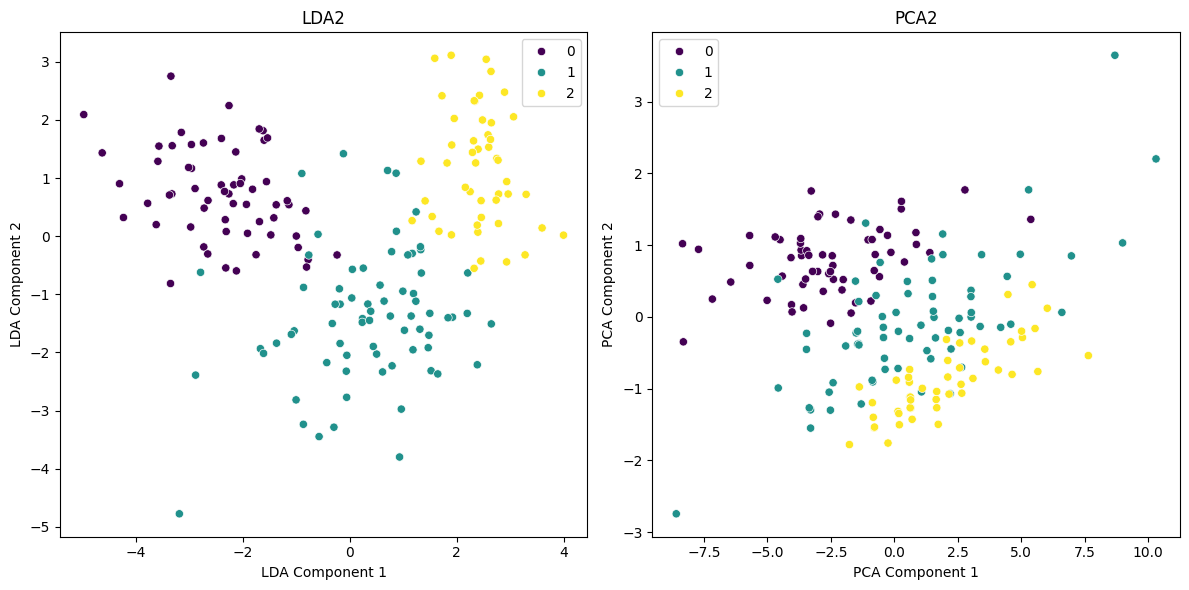

In [8]:
# 7. Визуализация пространств признаков LDA2 и PCA2
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, palette='viridis')
plt.title('LDA2')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis')
plt.title('PCA2')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

## Вывод:
LDA обеспечивает лучшее разделение между классами по сравнению с PCA, особенно между классом 0 (фиолетовый) и двумя другими классами.

PCA приводит к большему перекрытию между классами. Отчетливые кластеры менее очевидны.

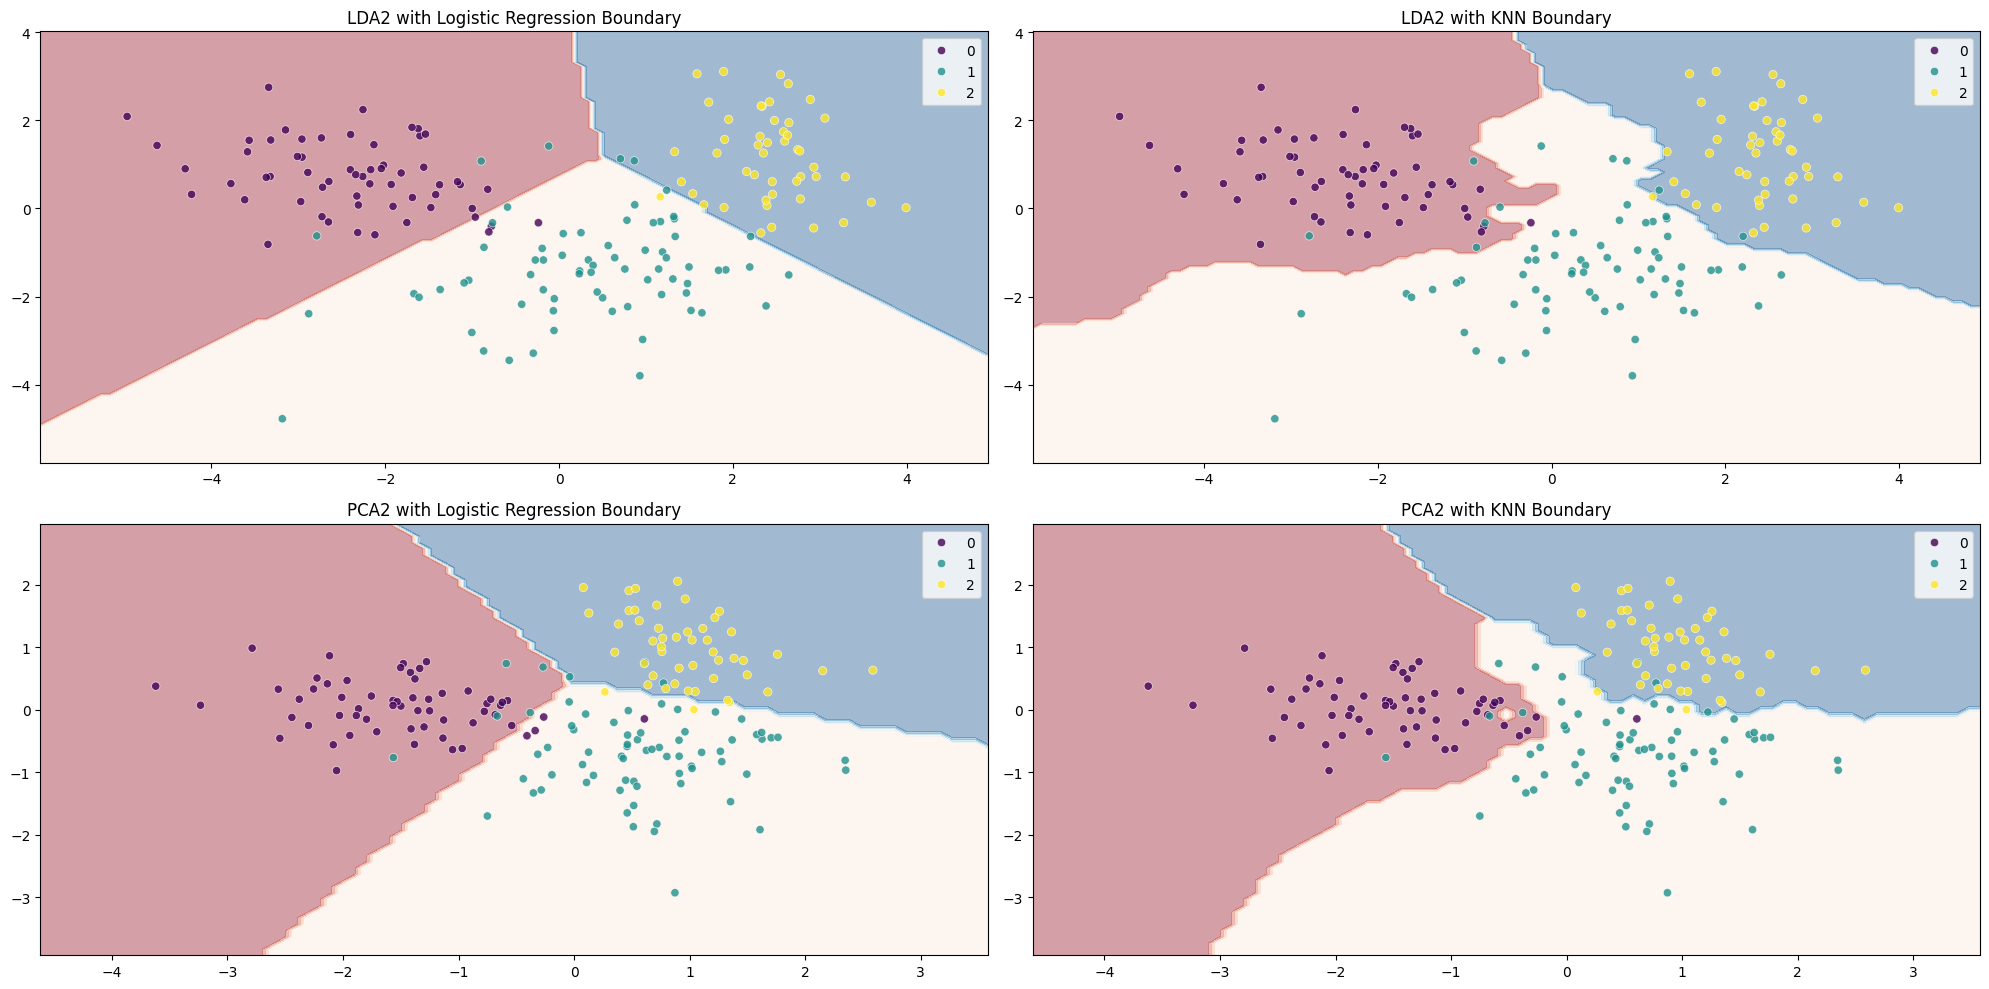

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# Функции для построения разделяющей границы
def plot_decision_boundary_lr(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.4)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, alpha=0.8, palette='viridis')
    plt.title(title)

def plot_decision_boundary_knn(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.4)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, alpha=0.8, palette='viridis')
    plt.title(title)

plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
lda_lr = LogisticRegression(random_state=42)
lda_lr.fit(X_lda, y)
plot_decision_boundary_lr(X_lda, y, lda_lr, 'LDA2 with Logistic Regression Boundary')
plt.subplot(2, 2, 2)
lda_knn = KNeighborsClassifier(n_neighbors=3)
lda_knn.fit(X_lda, y)
plot_decision_boundary_knn(X_lda, y, lda_knn, 'LDA2 with KNN Boundary')
plt.subplot(2, 2, 3)
pca_lr = LogisticRegression(random_state=42)
pca_lr.fit(X_pca, y)
plot_decision_boundary_lr(X_pca, y, pca_lr, 'PCA2 with Logistic Regression Boundary')
plt.subplot(2, 2, 4)
pca_knn = KNeighborsClassifier(n_neighbors=3)
pca_knn.fit(X_pca, y)
plot_decision_boundary_knn(X_pca, y, pca_knn, 'PCA2 with KNN Boundary')
plt.tight_layout()
plt.show()


## Вывод:
LDA2 в обоих случаях (с логистической регрессией и KNN) демонстрирует значительно лучшую разделимость классов. Границы решений, построенные после применения LDA2, более четко отделяют классы друг от друга, минимизируя перекрытие.

После применения PCA2 классы остаются более перемешанными. Границы решений менее эффективны в разделении классов, что приводит к большему количеству точек, попадающих в "чужие" регионы.

## **Вывод:**

Комбинация LDA с KNN, демонстрирует наилучшие результаты, поскольку LDA создает пространство признаков, в котором классы хорошо разделены.

### **На исходных признаках (без явного уменьшения размерности):**
На исходных признаках логистическая регрессия демонстрирует в целом более высокую и стабильную производительность по сравнению с KNN, за исключением класса 0, где KNN превосходит её по всем метрикам (Precision, Recall, F1-score). Для класса 1 логистическая регрессия имеет незначительно лучший F1-score и Recall, а для класса 2 — лучшие Precision и F1-score.

### **Влияние LDA:**
Использование двух компонент LDA (LDA2) привело к значительному улучшению производительности KNN, сделав его лучшим классификатором в этом сценарии по всем метрикам (Precision, Recall, F1-score) и по всем классам. Особенно выделяется идеальный Recall для класса 2 у KNN.
Логистическая регрессия, напротив, показала снижение производительности при использовании LDA2 по сравнению с исходными признаками.


### **Влияние PCA:**
Использование двух компонент PCA (PCA2) привело к значительному снижению производительности KNN по сравнению с исходными признаками.
Логистическая регрессия, напротив, сохранила высокую производительность, демонстрируя явное превосходство над KNN по всем классам и метрикам.


### **Комбинирование методов:**
Комбинирование первой компоненты LDA (LDA1) с двумя компонентами PCA (PCA2) улучшило результаты KNN по сравнению с использованием только PCA2, однако логистическая регрессия все еще демонстрирует лучшую общую производительность.
В классе 0 KNN превосходит логистическую регрессию по Recall, но уступает по Precision и F1-score.
Производительность логистической регрессии при комбинировании методов остается на высоком и стабильном уровне, сопоставимом с результатами на PCA2.
